
# Solutions Notebook: Simple Linear Regression with OLS

Complete, worked solutions to `02_Skeleton_Practice.ipynb`. Compare your
attempt against this notebook section by section — don't just read straight
through, since the point is to check your own reasoning, not to copy this.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import skewnorm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

sns.set_style("whitegrid")
RNG = np.random.default_rng(2022)


## Part A — OLS From Scratch

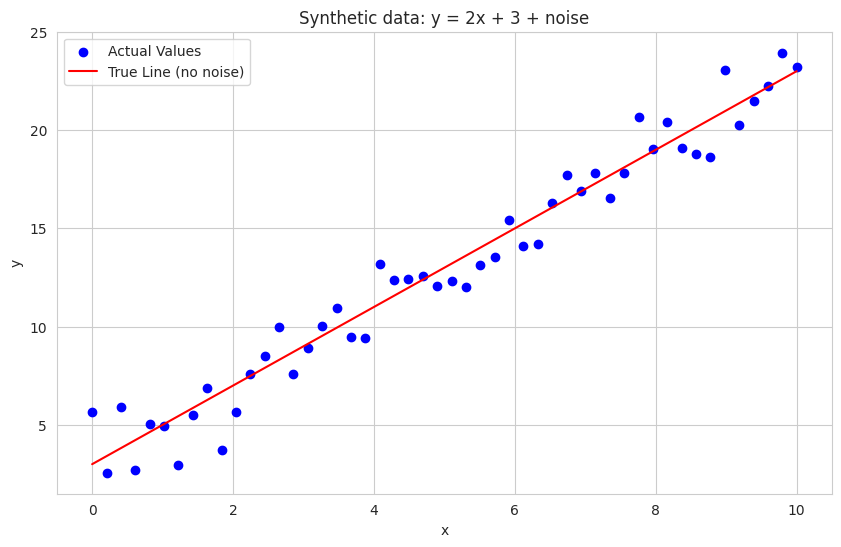

In [2]:
x = np.linspace(0, 10, 50)
noise = RNG.normal(0, 1, 50)
y = 2 * x + 3 + noise

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Actual Values')
plt.plot(x, 2 * x + 3, color='red', label='True Line (no noise)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Synthetic data: y = 2x + 3 + noise')
plt.legend()
plt.show()


In [3]:
def least_squares_method(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    beta1 = ((x - x_mean) * (y - y_mean)).sum(axis=0) / ((x - x_mean) ** 2).sum(axis=0)
    beta0 = y_mean - (beta1 * x_mean)
    return beta0, beta1

beta0_hat, beta1_hat = least_squares_method(x, y)
print(f"beta0_hat = {beta0_hat:.4f}  (true = 3)")
print(f"beta1_hat = {beta1_hat:.4f}  (true = 2)")


beta0_hat = 2.8451  (true = 3)
beta1_hat = 2.0116  (true = 2)


**Discussion:** With n=50 and unit-variance noise, `beta1_hat` typically lands
within about ±0.1-0.2 of the true value of 2, and `beta0_hat` within roughly
±0.3-0.5 of 3, though your exact numbers will differ from this text since it
depends on the random seed and noise draw actually used.

If you increase `n`, the standard error of both estimates shrinks
(proportional to `1/sqrt(n)` for the intercept and to `1/sqrt(Σ(x-x̄)²)` for
the slope) -- more data means less sampling variability. If you increase the
noise's standard deviation, the estimates become noisier / more variable
from run to run, but remain **unbiased on average** -- OLS doesn't
systematically over- or under-estimate the true slope, it just becomes less
*precise* with more noise or less data.

## Part B — Coefficients of Correlation and Determination

In [4]:
X = sm.add_constant(x)
model_A = sm.OLS(y, X).fit()

r = np.corrcoef(x, y)[0, 1]
r_squared_manual = r ** 2

ss_res = np.sum((y - model_A.fittedvalues) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared_from_ss = 1 - ss_res / ss_tot

print(f"Pearson r:              {r:.4f}")
print(f"r^2 (manual, r**2):     {r_squared_manual:.4f}")
print(f"r^2 (1 - SSres/SStot):  {r_squared_from_ss:.4f}")
print(f"statsmodels R-squared:  {model_A.rsquared:.4f}")


Pearson r:              0.9789
r^2 (manual, r**2):     0.9583
r^2 (1 - SSres/SStot):  0.9583
statsmodels R-squared:  0.9583


All three r² computations should agree to many decimal places (small differences, if any, are floating-point rounding) -- this confirms `R-squared` in the `statsmodels` summary is exactly the squared Pearson correlation in the single-predictor case.

## Part C — The Four Assumptions

### C.1 Linearity

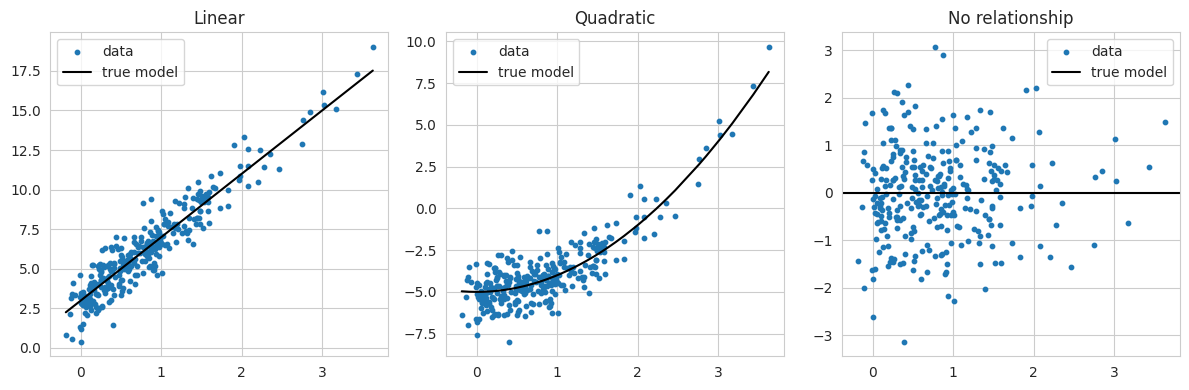

In [5]:
n_points = 300
noise300 = RNG.normal(size=n_points)
a = 10
x_skew = np.sort(skewnorm.rvs(a, size=n_points))

y_lin = x_skew * 4 + 3 + noise300
y_lin_true = x_skew * 4 + 3
y_quad = x_skew ** 2 - 5 + noise300
y_quad_true = x_skew ** 2 - 5
y_none = noise300

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].scatter(x_skew, y_lin, s=10, label='data'); ax[0].plot(x_skew, y_lin_true, c='k', label='true model')
ax[0].set_title('Linear'); ax[0].legend()
ax[1].scatter(x_skew, y_quad, s=10, label='data'); ax[1].plot(x_skew, y_quad_true, c='k', label='true model')
ax[1].set_title('Quadratic'); ax[1].legend()
ax[2].scatter(x_skew, y_none, s=10, label='data'); ax[2].axhline(0, c='k', label='true model')
ax[2].set_title('No relationship'); ax[2].legend()
fig.tight_layout()
plt.show()


**Predicted answer to the Think-About-It question:** fitting a straight line to the quadratic data would produce a Residuals-vs-Fitted plot with a clear U-shape (or inverted-U, depending on the curvature direction) -- residuals negative in the middle of the fitted-value range and positive at the extremes, or vice versa. Let's verify:

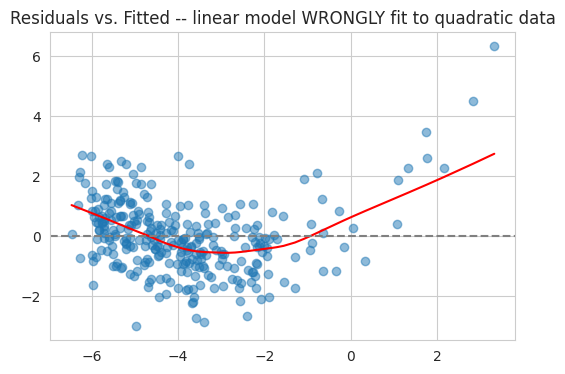

In [6]:
X_quad_wrong = sm.add_constant(x_skew)
model_quad_wrong = sm.OLS(y_quad, X_quad_wrong).fit()
resid_quad_wrong = model_quad_wrong.resid
fitted_quad_wrong = model_quad_wrong.fittedvalues

plt.figure(figsize=(6, 4))
lw = lowess(resid_quad_wrong, fitted_quad_wrong)
plt.scatter(fitted_quad_wrong, resid_quad_wrong, alpha=0.5)
plt.plot(lw[:, 0], lw[:, 1], color='red')
plt.axhline(0, color='grey', linestyle='--')
plt.title('Residuals vs. Fitted -- linear model WRONGLY fit to quadratic data')
plt.show()


Confirmed: the LOWESS trend line curves rather than staying flat -- a textbook sign of a mis-specified functional form.

### C.2 Normality of residuals despite skewed inputs

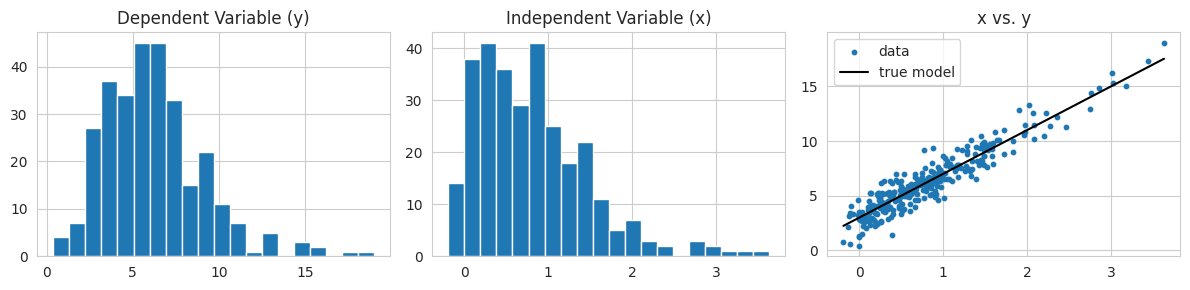

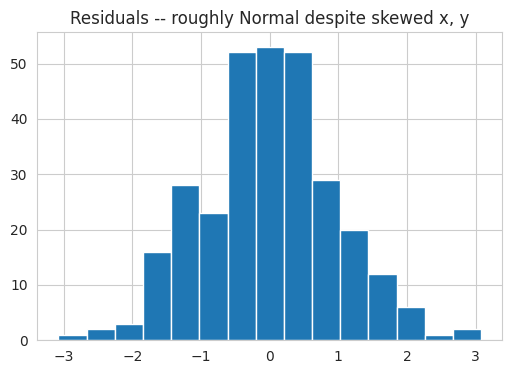

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].hist(y_lin, bins=20); ax[0].set_title("Dependent Variable (y)")
ax[1].hist(x_skew, bins=20); ax[1].set_title("Independent Variable (x)")
ax[2].scatter(x_skew, y_lin, s=10, label='data'); ax[2].plot(x_skew, y_lin_true, c='k', label='true model')
ax[2].set_title("x vs. y"); ax[2].legend()
fig.tight_layout()
plt.show()

X_lin = sm.add_constant(x_skew)
model_lin = sm.OLS(y_lin, X_lin).fit()
residuals_lin = model_lin.resid

plt.figure(figsize=(6, 4))
plt.hist(residuals_lin, bins=15)
plt.title("Residuals -- roughly Normal despite skewed x, y")
plt.show()


### C.3 Homoscedasticity, and two ways to break it

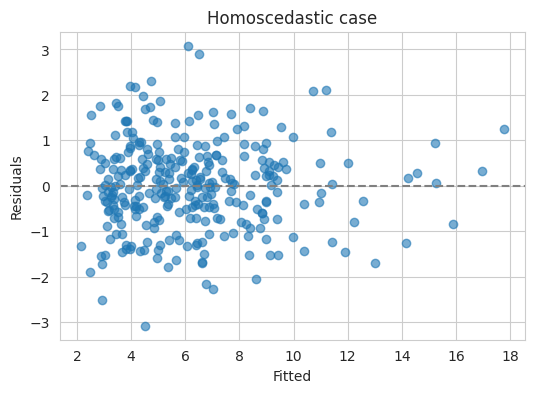

In [8]:
pred_lin = model_lin.predict(X_lin)
plt.figure(figsize=(6, 4))
plt.scatter(pred_lin, residuals_lin, alpha=0.6)
plt.axhline(0, color='grey', linestyle='--')
plt.title("Homoscedastic case")
plt.xlabel("Fitted"); plt.ylabel("Residuals")
plt.show()


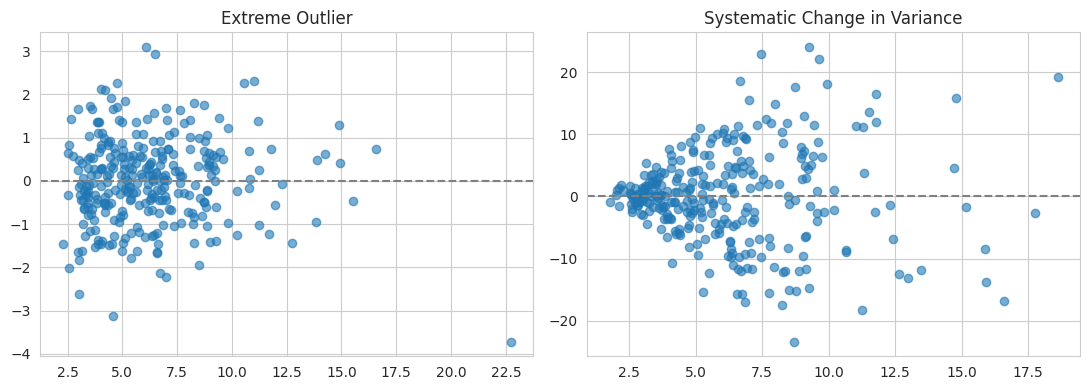

In [9]:
x_with_outlier = x_skew.copy()
x_with_outlier[-1] = 5
X_out = sm.add_constant(x_with_outlier)
model_out = sm.OLS(y_lin, X_out).fit()
pred_out = model_out.predict(X_out)
resid_out = model_out.resid

prop_noise = np.array([RNG.normal(0, i / 20, size=1)[0] for i in range(x_skew.size)])
y_growing = y_lin + prop_noise
X_grow = sm.add_constant(x_skew)
model_grow = sm.OLS(y_growing, X_grow).fit()
pred_grow = model_grow.predict(X_grow)
resid_grow = model_grow.resid

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(pred_out, resid_out, alpha=0.6); ax[0].axhline(0, color='grey', linestyle='--')
ax[0].set_title("Extreme Outlier")
ax[1].scatter(pred_grow, resid_grow, alpha=0.6); ax[1].axhline(0, color='grey', linestyle='--')
ax[1].set_title("Systematic Change in Variance")
fig.tight_layout()
plt.show()


**Discussion:** In the outlier panel, the vast majority of residuals sit in a
tight, well-behaved band -- it's really just one (or a few) points blowing
up the picture. Investigating and potentially correcting/removing THAT
specific record (after confirming it isn't a data-entry error worth keeping)
is a targeted fix.

In the growing-variance panel, the funnel shape is a *global* pattern across
the whole fitted-value range -- no single point is to blame. That calls for
a structural fix: a variance-stabilizing transformation of `y` (log, sqrt),
weighted least squares, or heteroscedasticity-robust standard errors
(`cov_type='HC3'`) rather than removing any specific observation.

### C.4 Independence

**Answer:** Linearity, normality, and homoscedasticity are all properties of
the *residual values themselves* -- you can compute them from the fitted
model and plot them directly. Independence, by contrast, is a claim about
the *relationships between* residuals (whether knowing one residual's value
or sign tells you anything about another's) that in general requires
knowing how the data were collected -- was it a simple random sample?
Repeated measures on the same subject? Sequential in time? A residual
scatter plot alone cannot rule out subtle dependence structures unless the
data happen to be explicitly ordered (e.g., by time), in which case tools
like the Durbin-Watson test and ACF/PACF plots can detect the special case
of serial (lag-based) dependence -- but that's a specific type of
dependence check, not a general one.

## Part D — Real Data: statsmodels macrodata

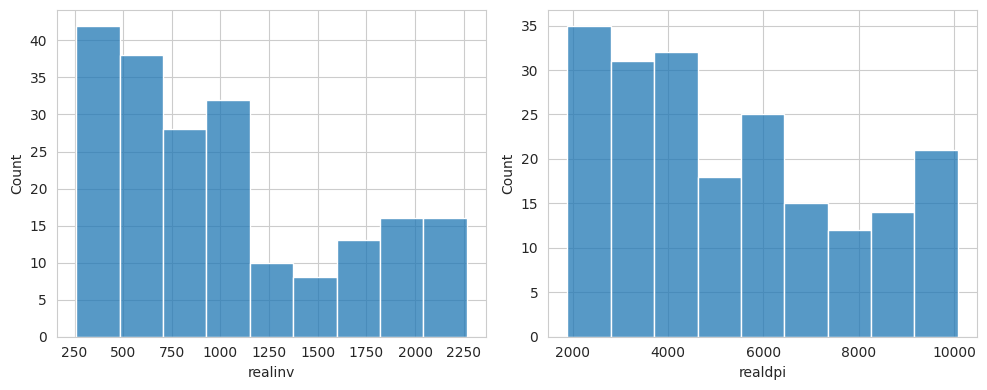

In [10]:
df = sm.datasets.macrodata.load().data
df = sm.add_constant(df, prepend=False)
df_mod = df[['realinv', 'realdpi', 'const']].copy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df_mod['realinv'], ax=ax[0])
sns.histplot(df_mod['realdpi'], ax=ax[1])
fig.tight_layout()
plt.show()


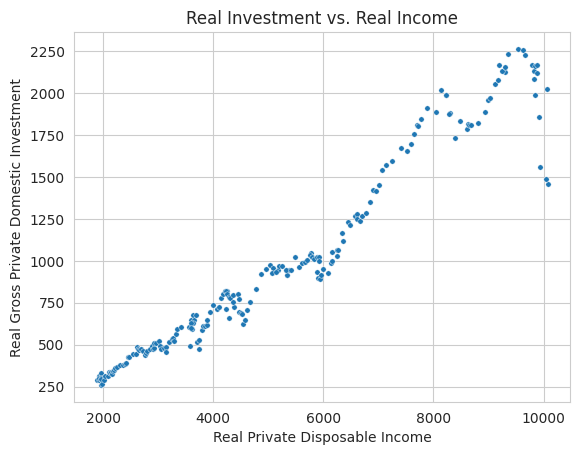

In [11]:
fig = sns.scatterplot(x=df_mod['realdpi'], y=df_mod['realinv'], s=15)
fig.set(xlabel="Real Private Disposable Income", ylabel="Real Gross Private Domestic Investment",
        title="Real Investment vs. Real Income")
plt.show()


In [12]:
ols_model = sm.OLS(df_mod['realdpi'], df_mod[['const', 'realinv']])
compiled_model = ols_model.fit()
print(compiled_model.summary())


                            OLS Regression Results                            
Dep. Variable:                realdpi   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     3384.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):          1.01e-127
Time:                        20:46:15   Log-Likelihood:                -1577.1
No. Observations:                 203   AIC:                             3158.
Df Residuals:                     201   BIC:                             3165.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1234.5164     80.866     15.266      0.0

**Answers:**
1. Yes -- `realinv`'s p-value is essentially 0.000 (far below 0.05), and its
   95% confidence interval does not contain zero, so it is a statistically
   significant predictor of `realdpi`.
2. R-squared is about 0.944 -- `realinv` explains roughly 94.4% of the
   variance in `realdpi`.
3. The Durbin-Watson statistic is about 0.095, far below the "no
   autocorrelation" benchmark of ~2. This strongly suggests positive serial
   correlation in the residuals -- expected, since this is 50 years of
   sequential quarterly macroeconomic data, not an independently sampled
   dataset. That means the p-values and confidence intervals above are
   probably too optimistic (understated standard errors).

## Part E — Diagnostic Plot Suite

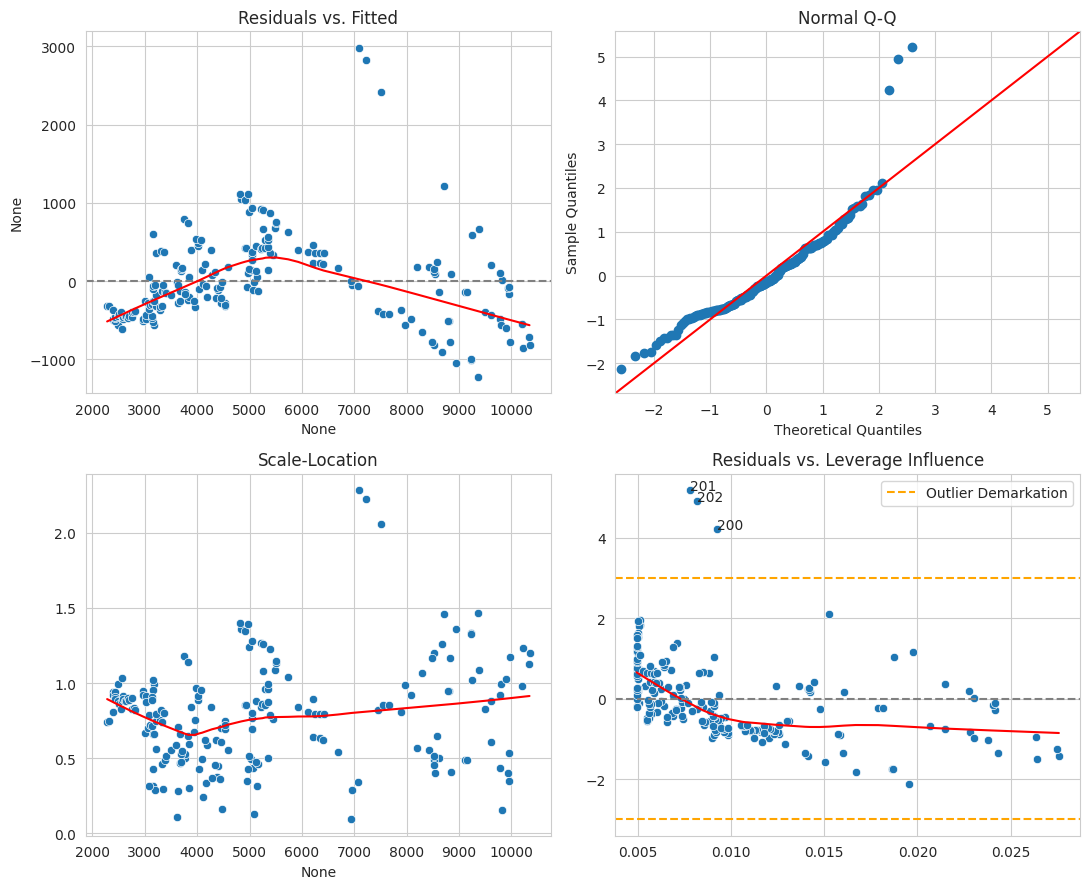

In [13]:
model_residuals = compiled_model.resid
fitted_value = compiled_model.fittedvalues
standardized_residuals = compiled_model.resid_pearson
sqrt_standardized_residuals = np.sqrt(np.abs(compiled_model.get_influence().resid_studentized_internal))
influence = compiled_model.get_influence()
leverage = influence.hat_matrix_diag
cooks_distance = compiled_model.get_influence().cooks_distance[0]

fig, ax = plt.subplots(2, 2, figsize=(11, 9))

lw1 = lowess(model_residuals, fitted_value)
sns.scatterplot(x=fitted_value, y=model_residuals, ax=ax[0, 0])
ax[0, 0].axhline(0, color='grey', linestyle='--')
ax[0, 0].plot(lw1[:, 0], lw1[:, 1], color='red')
ax[0, 0].set_title('Residuals vs. Fitted')

sm.qqplot(model_residuals, fit=True, line='45', ax=ax[0, 1])
ax[0, 1].set_title('Normal Q-Q')

lw2 = lowess(sqrt_standardized_residuals, fitted_value)
sns.scatterplot(x=fitted_value, y=sqrt_standardized_residuals, ax=ax[1, 0])
ax[1, 0].plot(lw2[:, 0], lw2[:, 1], color='red')
ax[1, 0].set_title('Scale-Location')

lw3 = lowess(standardized_residuals, leverage)
sns.scatterplot(x=leverage, y=standardized_residuals, ax=ax[1, 1])
ax[1, 1].plot(lw3[:, 0], lw3[:, 1], color='red')
ax[1, 1].axhline(0, color='grey', linestyle='--')
ax[1, 1].axhline(3, color='orange', linestyle='--', label='Outlier Demarkation')
ax[1, 1].axhline(-3, color='orange', linestyle='--')
ax[1, 1].legend(loc='upper right')
ax[1, 1].set_title('Residuals vs. Leverage Influence')

flagged = [i for i in range(len(cooks_distance)) if cooks_distance[i] > 0.5]
for i in flagged:
    ax[1, 1].annotate(f"{i}: Cook's D > 0.5", xy=(leverage[i], standardized_residuals[i]))
for i in range(len(standardized_residuals)):
    if abs(standardized_residuals[i]) > 3:
        ax[1, 1].annotate(i, xy=(leverage[i], standardized_residuals[i]))

fig.tight_layout()
plt.show()


**Answers (one sentence per panel):**
1. **Residuals vs. Fitted:** the LOWESS trend is clearly curved (rises then
   falls), meaning a straight line is not fully capturing the relationship --
   consistent with the "cyclical oscillation" the text notes visually in the
   raw scatter plot.
2. **Normal Q-Q:** points follow the 45° line reasonably well in the middle
   but bow away noticeably at the upper-right tail, indicating a handful of
   large positive residuals (right-skew / heavy right tail).
3. **Scale-Location:** the smoothed line is not flat -- it dips then rises,
   suggesting the residual spread is not perfectly constant across the range
   of fitted values (mild heteroscedasticity risk).
4. **Residuals vs. Leverage:** a few points stand out with standardized
   residuals beyond the ±3 outlier lines, but none reach a Cook's distance
   above 0.5, so while there are notable outliers, none of them individually
   dominates the model fit.

## Part F — Serial Correlation: Durbin-Watson, ACF/PACF, Differencing

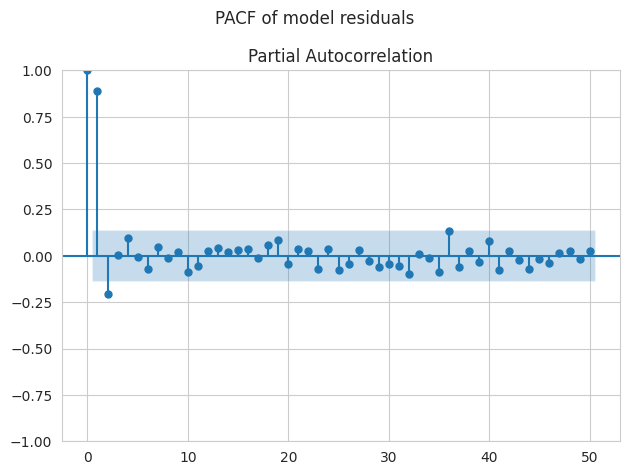

In [14]:
fig = plot_pacf(compiled_model.resid, alpha=0.05, lags=50)
fig.suptitle("PACF of model residuals")
fig.tight_layout()
plt.show()


The PACF shows a very large, significant spike at lag 1 (and a smaller significant dip further out), confirming strong lag-1 (first-order) autocorrelation -- exactly what the near-zero Durbin-Watson statistic predicted.

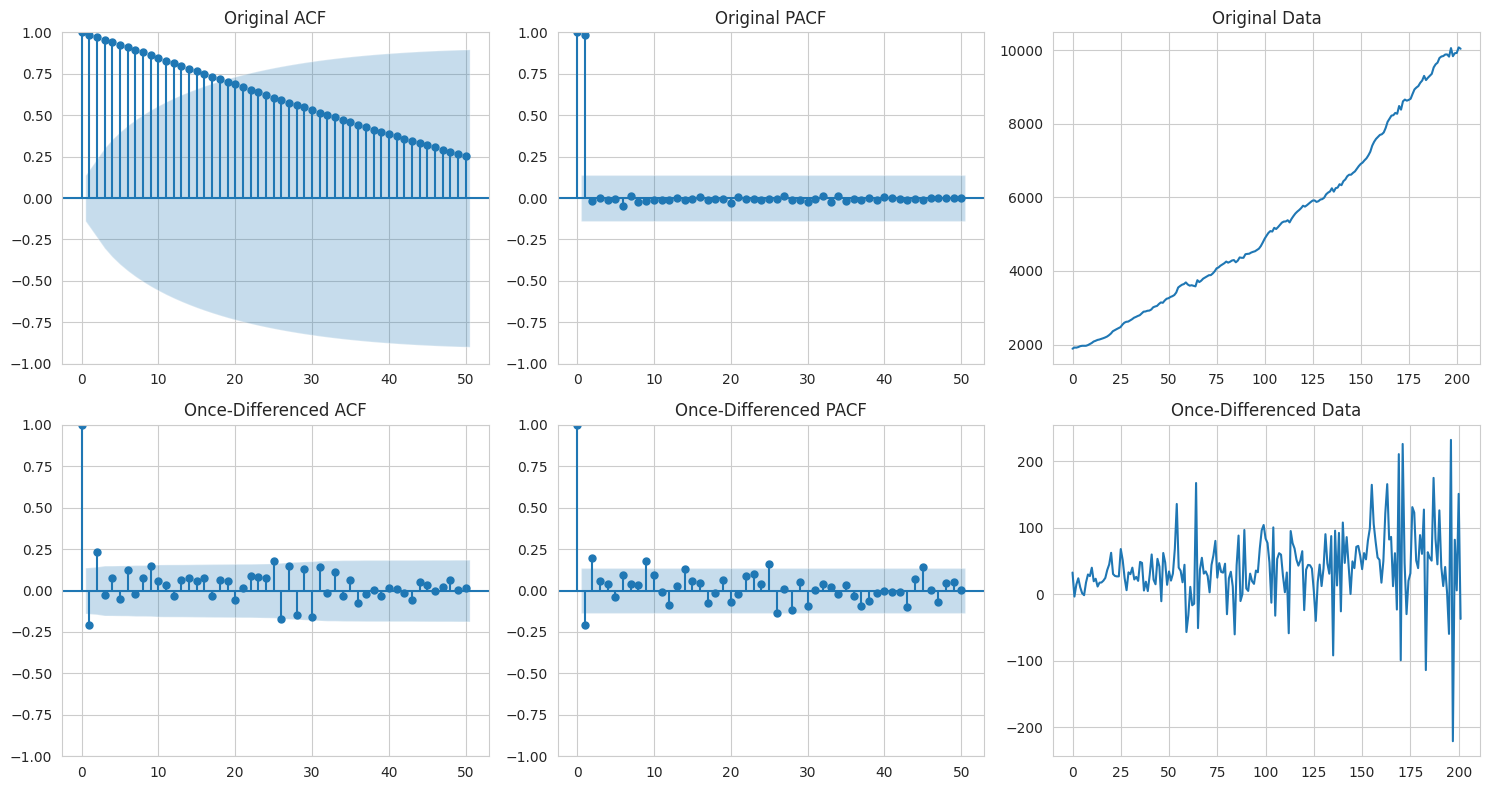

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
plot_acf(df_mod['realdpi'], alpha=0.05, lags=50, ax=ax[0, 0]); ax[0, 0].set_title('Original ACF')
plot_pacf(df_mod['realdpi'], alpha=0.05, lags=50, ax=ax[0, 1]); ax[0, 1].set_title('Original PACF')
ax[0, 2].set_title('Original Data'); ax[0, 2].plot(df_mod['realdpi'])

plot_acf(np.diff(df_mod['realdpi'], n=1), alpha=0.05, lags=50, ax=ax[1, 0]); ax[1, 0].set_title('Once-Differenced ACF')
plot_pacf(np.diff(df_mod['realdpi'], n=1), alpha=0.05, lags=50, ax=ax[1, 1]); ax[1, 1].set_title('Once-Differenced PACF')
ax[1, 2].set_title('Once-Differenced Data'); ax[1, 2].plot(np.diff(df_mod['realdpi'], n=1))

fig.tight_layout()
plt.show()


In [16]:
ols_model_1diff = sm.OLS(
    np.diff(df_mod['realdpi'], n=1),
    pd.concat([df_mod['const'].iloc[:-1], pd.Series(np.diff(df_mod['realinv'], n=1))], axis=1)
)
compiled_model_1diff = ols_model_1diff.fit()
print(compiled_model_1diff.summary())
print("\nDurbin-Watson (differenced model):", durbin_watson(compiled_model_1diff.resid))


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     9.437
Date:                Wed, 26 Aug 2026   Prob (F-statistic):            0.00242
Time:                        20:46:16   Log-Likelihood:                -1085.6
No. Observations:                 202   AIC:                             2175.
Df Residuals:                     200   BIC:                             2182.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.8531      3.724     10.433      0.0

**Answers:**
1. R-squared drops from ~0.944 to roughly 0.04-0.05. The levels model was
   largely capturing the fact that BOTH series trend upward together over
   50 years (a shared trend), which is easy to "explain" with high R² but is
   not very informative. Differencing removes the trend and leaves only the
   quarter-to-quarter *changes*, which are far more weakly related --
   `realinv` changes explain very little of `realdpi` changes.
2. The differenced model's Durbin-Watson statistic comes out around 2.4-2.5,
   which is now *above* the upper bound needed to rule out negative
   autocorrelation (recall from the background reading: positive-autocorrelation
   bounds ≈[1.758, 1.779] and, by symmetry, negative-autocorrelation bounds
   ≈[2.221, 2.242] for n≈200, k=1). A value above 2.221 suggests mild
   *negative* autocorrelation remains, though much less severe than the
   strong positive autocorrelation in the levels model.
3. Even though differencing greatly reduced the autocorrelation problem, some
   residual dependence remains, and the differenced relationship is much
   weaker (low R²) and answers a different question (rates of change, not
   levels) than what we originally wanted to explain. A dedicated
   time-series model (e.g., an ARMA/VAR model) can jointly model the
   dynamics of both series properly, rather than papering over
   autocorrelation with a single fixed-order difference.

## Part G — Model Validation: Train/Test Split & Naive Baseline

In [17]:
train, test = train_test_split(df_mod, train_size=0.75, shuffle=True, random_state=42)

ols_model_train = sm.OLS(train['realdpi'], train[['const', 'realinv']])
compiled_model_train = ols_model_train.fit()
print(compiled_model_train.summary())


                            OLS Regression Results                            
Dep. Variable:                realdpi   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     2752.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           2.11e-98
Time:                        20:46:16   Log-Likelihood:                -1176.4
No. Observations:                 152   AIC:                             2357.
Df Residuals:                     150   BIC:                             2363.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1176.6560     91.027     12.927      0.0

In [18]:
ols_model_test = sm.OLS(test['realdpi'], test[['const', 'realinv']])
compiled_model_test = ols_model_test.fit()
print(compiled_model_test.summary())


                            OLS Regression Results                            
Dep. Variable:                realdpi   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     666.9
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           3.43e-30
Time:                        20:46:16   Log-Likelihood:                -399.51
No. Observations:                  51   AIC:                             803.0
Df Residuals:                      49   BIC:                             806.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1405.7460    173.982      8.080      0.0

**Discussion:** the `realinv` coefficient and R-squared should be quite close between the train-only and test-only fits (typically within a small fraction of each other) -- reassuring evidence that the relationship is stable across random subsets of the data, rather than being an artifact of a few particular rows.

In [19]:
mae_train = mean_absolute_error(train['realdpi'], compiled_model_train.predict(train[['const', 'realinv']]))
naive_mae_train = np.mean(np.abs(train['realdpi'] - train['realdpi'].mean()))

mae_holdout = mean_absolute_error(test['realdpi'], compiled_model_train.predict(test[['const', 'realinv']]))
naive_mae_test = np.mean(np.abs(test['realdpi'] - test['realdpi'].mean()))

print(f"Train MAE (model):        {mae_train:10.2f}")
print(f"Train MAE (naive mean):   {naive_mae_train:10.2f}")
print(f"Holdout MAE (model):      {mae_holdout:10.2f}")
print(f"Holdout MAE (naive mean): {naive_mae_test:10.2f}")


Train MAE (model):            394.42
Train MAE (naive mean):      2068.82
Holdout MAE (model):          476.85
Holdout MAE (naive mean):    1999.33


The fitted model's MAE should be roughly 4-5x smaller than the naive baseline's MAE, on both the train and holdout partitions, and the model's train vs. holdout MAE should be in a similar ballpark -- consistent evidence the model generalizes and clearly beats a trivial baseline (though recall from Part F/D that the model still likely has unresolved serial correlation, which the MAE comparison does not detect).

## Part H — Extension Exercises: Worked Solutions

### H.1 Simulation study of the sampling distribution of β̂1

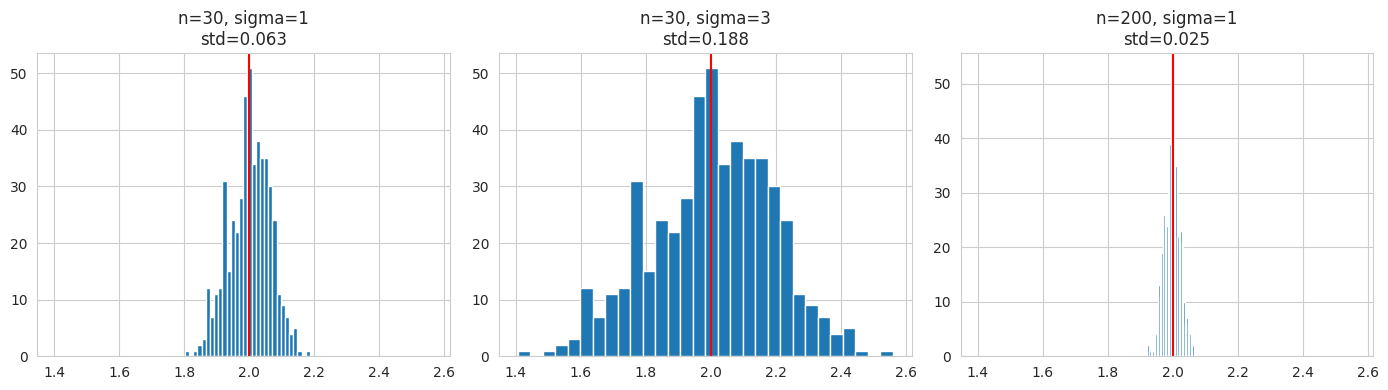

In [20]:
def simulate_beta1_distribution(n=30, sigma=1.0, n_sims=500, rng=None):
    if rng is None:
        rng = np.random.default_rng(1)
    estimates = []
    x_sim = np.linspace(0, 10, n)
    for _ in range(n_sims):
        y_sim = 2 * x_sim + 3 + rng.normal(0, sigma, n)
        _, b1 = least_squares_method(x_sim, y_sim)
        estimates.append(b1)
    return np.array(estimates)

estimates_baseline = simulate_beta1_distribution(n=30, sigma=1.0)
estimates_more_noise = simulate_beta1_distribution(n=30, sigma=3.0)
estimates_more_data = simulate_beta1_distribution(n=200, sigma=1.0)

fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
ax[0].hist(estimates_baseline, bins=30); ax[0].axvline(2, color='red')
ax[0].set_title(f"n=30, sigma=1\nstd={estimates_baseline.std():.3f}")
ax[1].hist(estimates_more_noise, bins=30); ax[1].axvline(2, color='red')
ax[1].set_title(f"n=30, sigma=3\nstd={estimates_more_noise.std():.3f}")
ax[2].hist(estimates_more_data, bins=30); ax[2].axvline(2, color='red')
ax[2].set_title(f"n=200, sigma=1\nstd={estimates_more_data.std():.3f}")
fig.tight_layout()
plt.show()


All three histograms center on the true value of 2 (unbiasedness), but the spread widens with more noise and narrows with more data -- a direct empirical illustration of the OLS slope's standard error formula.

### H.2 Heteroscedasticity-robust standard errors

In [21]:
model_default = sm.OLS(df_mod['realdpi'], df_mod[['const', 'realinv']]).fit()
model_robust = sm.OLS(df_mod['realdpi'], df_mod[['const', 'realinv']]).fit(cov_type='HC3')

comparison = pd.DataFrame({
    'coef': model_default.params,
    'se (nonrobust)': model_default.bse,
    'se (HC3)': model_robust.bse,
    'p-value (nonrobust)': model_default.pvalues,
    'p-value (HC3)': model_robust.pvalues,
})
comparison


,coef,se (nonrobust),se (HC3),p-value (nonrobust),p-value (HC3)
const,1234.516397,80.865932,64.564677,1.908759e-35,1.700868e-81
realinv,4.024257,0.069176,0.072548,1.008892e-127,0.000000e+00


The coefficients are identical (robust SEs don't change the point estimates, only their uncertainty). The HC3 standard errors typically differ somewhat from the nonrobust ones, but in this particular case the `realinv` p-value remains far below 0.05 either way -- the significance conclusion is unchanged, although in general robust SEs can flip a borderline result.

### H.3 Alternative predictor

In [22]:
df_full = sm.datasets.macrodata.load().data
df_full = sm.add_constant(df_full, prepend=False)

model_gdp = sm.OLS(df_full['realdpi'], df_full[['const', 'realgdp']]).fit()
print(model_gdp.summary())
print("\nDurbin-Watson:", durbin_watson(model_gdp.resid))


                            OLS Regression Results                            
Dep. Variable:                realdpi   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.012e+05
Date:                Wed, 26 Aug 2026   Prob (F-statistic):          1.34e-273
Time:                        20:46:17   Log-Likelihood:                -1237.9
No. Observations:                 203   AIC:                             2480.
Df Residuals:                     201   BIC:                             2486.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -127.5636     18.707     -6.819      0.0

`realgdp` is also a strong, significant predictor of `realdpi` with a similarly high R-squared -- unsurprising, since GDP and disposable income are both broad, trending macroeconomic aggregates. The Durbin-Watson statistic is similarly very low here too, so this predictor is **not** better-behaved with respect to independence -- the same trending-time-series problem applies to essentially any macro variable used this way.

### H.4 Outlier sensitivity

In [23]:
X_clean = sm.add_constant(x_skew)
model_clean = sm.OLS(y_lin, X_clean).fit()

X_outlier = sm.add_constant(x_with_outlier)
model_with_outlier = sm.OLS(y_lin, X_outlier).fit()

print(f"beta1 without outlier: {model_clean.params[1]:.4f}")
print(f"beta1 with outlier:    {model_with_outlier.params[1]:.4f}")
print(f"Cook's distance of the modified point: "
      f"{model_with_outlier.get_influence().cooks_distance[0][-1]:.4f}")


beta1 without outlier: 4.0914
beta1 with outlier:    3.9412
Cook's distance of the modified point: 1.1217


In this example the single modified point typically shifts `beta1_hat` only slightly (because n=300 dilutes any one point's influence) and its Cook's distance is small -- illustrating that a single outlier is not automatically influential; leverage (how extreme the point is in x) matters as much as the size of its residual.

### H.5 Re-deriving the OLS estimator (self-check)

In [24]:
def least_squares_from_normal_equations(x, y):
    """
    Re-derivation, independent of the earlier implementation, to sanity-check
    against statsmodels.
    beta1 = Sum((x - xbar)(y - ybar)) / Sum((x - xbar)^2)
    beta0 = ybar - beta1 * xbar
    """
    xbar, ybar = np.mean(x), np.mean(y)
    numerator = np.sum((x - xbar) * (y - ybar))
    denominator = np.sum((x - xbar) ** 2)
    b1 = numerator / denominator
    b0 = ybar - b1 * xbar
    return b0, b1

b0_check, b1_check = least_squares_from_normal_equations(x, y)
sm_check = sm.OLS(y, sm.add_constant(x)).fit()

print(f"Hand-derived:  beta0={b0_check:.6f}, beta1={b1_check:.6f}")
print(f"statsmodels:   beta0={sm_check.params[0]:.6f}, beta1={sm_check.params[1]:.6f}")


Hand-derived:  beta0=2.845118, beta1=2.011594
statsmodels:   beta0=2.845118, beta1=2.011594


The two should match to numerical precision, confirming the closed-form estimator is correctly implemented.